# 🩺 Example 2: Diabetes Prediction with Support Vector Machines (SVM)

This notebook constructs and evaluates a **Support Vector Machine (SVM)** classifier to predict whether a patient is **diabetic (1)** or **non-diabetic (0)** using the **Pima Indians Diabetes** dataset.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1) Load and Inspect the Dataset
The dataset records medical measurements from female patients of Pima Indian heritage.  
Each row represents a single patient, containing **8 numeric health indicators** such as glucose level, blood pressure, and BMI.  
The target column **`Outcome`** is binary:  
- **0** indicates a non-diabetic patient  
- **1** indicates a diabetic patient  

In [ ]:
# Load the dataset (ensure 'Example_2_Diabetes_SVM.csv' is present in the working directory)
df = pd.read_csv("Example_2_Diabetes_SVM.csv")

# Show dataset shape and the first few rows for a quick structural check
print("Dataset shape:", df.shape)
df.head()

# Display how many patients belong to each class (0 = Non-diabetic, 1 = Diabetic)
print("\nClass distribution (Outcome):")
print(df["Outcome"].value_counts())

# Check if there are any missing (NaN) values in the dataset
# Note: Some medical features may contain zeros that represent missing values (not NaN)
print("\nMissing values (NA counts):")
print(df.isna().sum().sum())

# Show summary statistics for each numeric feature
# Includes mean, standard deviation, min, max, and quartile values
print("\nFeature summary (first few features):")
df.describe().T.head()

Dataset shape: (768, 9)

Class distribution (Outcome):
Outcome
0    500
1    268
Name: count, dtype: int64

Missing values (NA counts):
0

Feature summary (first few features):


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.0,1.0,3.0,6.00,17.0
Glucose,768.0,120.894531,31.972618,0.0,99.0,117.0,140.25,199.0
BloodPressure,768.0,69.105469,19.355807,0.0,62.0,72.0,80.00,122.0
SkinThickness,768.0,20.536458,15.952218,0.0,0.0,23.0,32.00,99.0
Insulin,768.0,79.799479,115.244002,0.0,0.0,30.5,127.25,846.0


## 2) Separate Features and Label

The dataset is divided into two components for model training:  
- **Features (X):** the eight medical measurements used as input variables.  
- **Label (y):** the target column `Outcome`, indicating whether the patient is diabetic (1) or non-diabetic (0).  

In [ ]:
# Separate input features (8 clinical measurements) and target label
X = df.drop(columns=["Outcome"]).astype(float)
y = df["Outcome"].astype(int)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (768, 8)
Label vector shape: (768,)


## 3) Split into Training and Test Sets

The dataset is divided into two parts to evaluate model performance on unseen data:  
- **80%** of the samples are used for training the model.  
- **20%** are reserved for testing and validation.  

The parameter `stratify=y` ensures that the ratio of diabetic to non-diabetic patients remains consistent in both subsets, providing a balanced and fair evaluation.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,   # 20% for testing
    stratify=y,       # preserve class ratio
    random_state=2    # reproducible split
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (614, 8)
Test size : (154, 8)


## 4) Standardize Features

Support Vector Machines (SVM) use geometric distances to find the best separating line (or hyperplane) between classes.  
Because of this, the algorithm is **very sensitive to the scale of input features**.

For example, if one feature (like *Glucose*) ranges from 0–200, and another (like *DiabetesPedigreeFunction*) ranges from 0–2,  
the feature with the larger range will dominate the distance calculation, making the model biased toward that feature.

To prevent this, all features are **standardized** using `StandardScaler` from scikit-learn.  
This transformation adjusts each feature so that:
- The **mean** becomes **0**  
- The **standard deviation** becomes **1**

After scaling, all features are on the same scale, which helps the SVM algorithm:
- Train faster and more stably  
- Find an optimal separating boundary (margin) more accurately  
- Produce better, more balanced predictions

In [ ]:
# Initialize the StandardScaler to perform feature standardization
scaler = StandardScaler()

# Fit the scaler only on the training data to learn scaling parameters (mean and std)
# Then apply the same transformation to both training and test sets
# This prevents data leakage from the test set into the training process
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

print("Standardization complete.")

Standardization complete.


## 5) Train the SVM Classifier

A **Support Vector Machine (SVM)** is a supervised machine learning algorithm used for classification and regression tasks.  
- In classification, its main objective is to find the **best possible boundary** that separates data points belonging to different classes.  
    - This boundary is known as a **hyperplane**.  
    - SVM chooses the hyperplane that **maximizes the margin**, which is the distance between the boundary and the nearest data points from each class.  
    - These closest data points are called **support vectors** because they are the most critical elements in defining the position and orientation of the hyperplane.  

By maximizing the margin, SVM creates a decision boundary that is both **robust** (less sensitive to noise) and **generalizes well** to unseen data.

### 🔹 Linear Kernel
- A **linear kernel** is used in this model, which assumes that the classes can be separated by a straight line (in 2D) or a flat plane (in higher dimensions).  
- This is often effective when the data has a mostly linear relationship between input features and the target variable.

### 🔹 Soft Margins and Regularization
In real-world data, perfect separation between classes is rarely possible.  
SVM allows some misclassifications using **soft margins**, controlled by the **regularization parameter `C`**:
- A **large `C`** value tries to classify all training points correctly but may lead to overfitting.
- A **small `C`** value allows more flexibility (wider margin) but may slightly reduce accuracy on the training data.

By default, `C=1.0`, providing a balanced trade-off between margin width and classification accuracy.

The model learns the position of the optimal hyperplane using the training data, which is then used to classify new, unseen samples.

**References:**  
- [scikit-learn: Support Vector Machines](https://scikit-learn.org/stable/modules/svm.html)  
- [scikit-learn API: `SVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)


In [ ]:
# Initialize a Support Vector Machine (SVM) classifier
# kernel='linear' → uses a linear decision boundary (suitable for linearly separable data)
# random_state=2  → ensures reproducible results by fixing randomization during model training
model = SVC(kernel='linear', random_state=2)

# Train the SVM model using the standardized training data
# The model learns the optimal hyperplane that separates diabetic and non-diabetic patients
model.fit(X_train_std, y_train)

print("Model training completed successfully.")

Model training completed successfully.


## 6) Evaluate Model Performance

After training, the model’s performance is evaluated to understand how accurately it predicts unseen data.

The following metrics are used:

- **Accuracy:** Measures the overall percentage of correct predictions on both the training and test sets.  
- **Confusion Matrix:** Displays the counts of correct and incorrect predictions for each class, helping to identify which types of errors the model makes.  
- **Classification Report:** Provides three key metrics for each class:  
  **Precision** indicates how many of the samples predicted as positive are actually positive.  
  **Recall** measures how many of the actual positive samples are correctly identified.  
  **F1-Score** combines precision and recall into a single balanced measure.

Training accuracy: 0.787
Testing  accuracy: 0.773


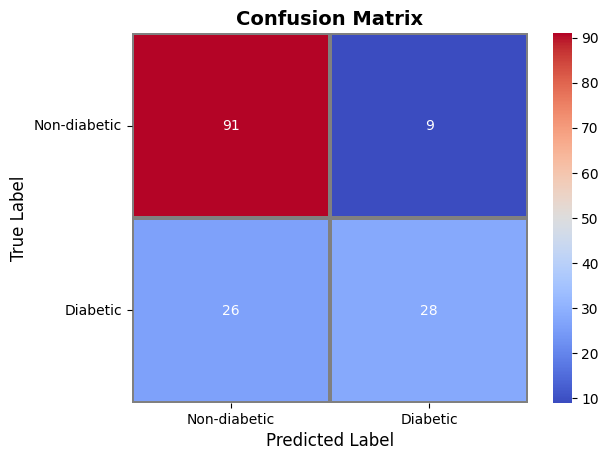


Classification Report:

              precision    recall  f1-score   support

Non-diabetic       0.78      0.91      0.84       100
    Diabetic       0.76      0.52      0.62        54

    accuracy                           0.77       154
   macro avg       0.77      0.71      0.73       154
weighted avg       0.77      0.77      0.76       154



In [ ]:
# ---------------------------------------------------------------------
# Generate predictions using the trained SVM model
# ---------------------------------------------------------------------
train_pred = model.predict(X_train_std)
test_pred  = model.predict(X_test_std)

# ---------------------------------------------------------------------
# Calculate and display accuracy scores
# ---------------------------------------------------------------------
print(f"Training accuracy: {accuracy_score(y_train, train_pred):.3f}")
print(f"Testing  accuracy: {accuracy_score(y_test,  test_pred):.3f}")

# ---------------------------------------------------------------------
# Create and visualize the confusion matrix
# ---------------------------------------------------------------------
cm = confusion_matrix(y_test, test_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            cbar=True, linewidths=1.5, linecolor='gray',
            xticklabels=['Non-diabetic', 'Diabetic'],
            yticklabels=['Non-diabetic', 'Diabetic'])

plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

# ---------------------------------------------------------------------
# Generate a detailed classification report
# ---------------------------------------------------------------------
print("\nClassification Report:\n")
print(classification_report(y_test, test_pred, target_names=['Non-diabetic', 'Diabetic']))

## 7) Predict for a Single Patient

Once the model has been trained, it can be used to make predictions for new patients based on their medical measurements.  
- The function below accepts a set of **eight input values** that must follow the **same feature order** used during model training.

Before prediction, the input data is standardized using the **same scaler** that was fitted on the training set.  
- This ensures the new data is transformed consistently with the data the model was trained on, allowing for accurate and reliable predictions of whether the patient is **diabetic** or **non-diabetic**.

In [ ]:
# ---------------------------------------------------------------------
# DEFINE THE EXPECTED FEATURE ORDER
# ---------------------------------------------------------------------
# The order of features must match exactly how the model was trained.
# This ensures the correct values are assigned to the corresponding features.
FEATURE_ORDER = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"
]

# ---------------------------------------------------------------------
# FUNCTION: Predict diabetes for a single patient
# ---------------------------------------------------------------------
def predict_one(row_in_feature_order):
    """
    Predicts whether a patient is diabetic or non-diabetic based on their medical measurements.

    Parameters:
        row_in_feature_order (list): A list of 8 numeric values representing a single patient,
                                     following the order defined in FEATURE_ORDER.

    Returns:
        str: "Diabetic" or "Non-diabetic" based on the model's prediction.
    """
    # Convert the input list into a DataFrame with appropriate column names
    arr_df = pd.DataFrame([row_in_feature_order], columns=FEATURE_ORDER)

    # Apply the same standardization as used during training
    # This step ensures consistency between new input data and the training data
    arr_std = scaler.transform(arr_df)

    # Use the trained SVM model to make a prediction (0 = Non-diabetic, 1 = Diabetic)
    pred = model.predict(arr_std)[0]

    # Return the corresponding label as a readable string
    return "Diabetic" if pred == 1 else "Non-diabetic"

# ---------------------------------------------------------------------
# TEST THE FUNCTION USING ONE SAMPLE FROM THE TEST SET
# ---------------------------------------------------------------------
# Select one real patient record from the test dataset
example = X_test.iloc[0].to_list()

print("Prediction:", predict_one(example))

Prediction: Non-diabetic
